# ADE20K — Semantic Segmentation


## 1. Setup & Installs

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q pycocotools segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.1 MB/s eta 0:00:00


In [3]:
import os, json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from pycocotools.coco import COCO
from pycocotools import mask as maskUtils
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
EXTRACT_DIR = "/content/drive/MyDrive/dataset/image_segmentation_dataset"

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

print(os.listdir(EXTRACT_DIR))

['instances_train.json', 'instances_val.json', 'train', 'test', 'val', 'RMDS_segmentation_dataset_ADE20K_350.zip']


## 2. Load Annotations

In [5]:
TRAIN_ANN = os.path.join(EXTRACT_DIR, "instances_train.json")
VAL_ANN   = os.path.join(EXTRACT_DIR, "instances_val.json")
TRAIN_DIR = os.path.join(EXTRACT_DIR, "train")
VAL_DIR   = os.path.join(EXTRACT_DIR, "val")
TEST_DIR  = os.path.join(EXTRACT_DIR, "test")

coco_train = COCO(TRAIN_ANN)
coco_val   = COCO(VAL_ANN)

with open(TRAIN_ANN) as f:
    train_json = json.load(f)
with open(VAL_ANN) as f:
    val_json = json.load(f)

TARGET_CATEGORIES = {4: "person", 9: "car", 40: "book", 59: "airplane"}
CAT_ID_TO_LABEL = {4: 1, 9: 2, 40: 3, 59: 4}
CLASS_NAMES = ["background", "person", "car", "book", "airplane"]

print("Train images:", len(train_json["images"]), "| Train annotations:", len(train_json["annotations"]))
print("Val images:", len(val_json["images"]), "| Val annotations:", len(val_json["annotations"]))

loading annotations into memory...
Done (t=0.71s)
creating index...
index created!
loading annotations into memory...
Done (t=1.24s)
creating index...
index created!
Train images: 350 | Train annotations: 5111
Val images: 350 | Val annotations: 5803


## 3. Exploratory Data Analysis (EDA)
### 3.1 Missing value / data integrity checks
Checks required for a segmentation task specifically:
- Every image referenced in the JSON actually exists on disk
- Every image file opens correctly (not corrupt) and is real RGB
- No orphan annotations (annotation pointing to a non-existent image_id)
- No annotations with null/empty segmentation, zero area, or invalid RLE
- Recorded width/height in JSON match the actual image dimensions (mask/image shape mismatch is a common silent bug)
- No duplicate annotation IDs
- Images with zero target-class annotations (won't contribute foreground signal)

In [6]:
def check_missing_images(json_data, img_dir, split_name):
    missing = []
    unreadable = []
    dim_mismatch = []
    for img in json_data["images"]:
        path = os.path.join(img_dir, img["file_name"])
        if not os.path.exists(path):
            missing.append(img["file_name"])
            continue
        try:
            with Image.open(path) as im:
                im.verify()
            with Image.open(path) as im:
                w, h = im.size
                if (w, h) != (img["width"], img["height"]):
                    dim_mismatch.append((img["file_name"], (w, h), (img["width"], img["height"])))
        except Exception as e:
            unreadable.append((img["file_name"], str(e)))

    print(f"--- {split_name} ---")
    print(f"Missing files: {len(missing)}")
    print(f"Unreadable/corrupt files: {len(unreadable)}")
    print(f"Width/height mismatches (JSON vs actual file): {len(dim_mismatch)}")
    if missing: print("  e.g.", missing[:5])
    if unreadable: print("  e.g.", unreadable[:5])
    if dim_mismatch: print("  e.g.", dim_mismatch[:5])
    return missing, unreadable, dim_mismatch

train_missing, train_unreadable, train_dim_mismatch = check_missing_images(train_json, TRAIN_DIR, "train")
val_missing, val_unreadable, val_dim_mismatch = check_missing_images(val_json, VAL_DIR, "val")

--- train ---
Missing files: 0
Unreadable/corrupt files: 0
Width/height mismatches (JSON vs actual file): 0
--- val ---
Missing files: 0
Unreadable/corrupt files: 0
Width/height mismatches (JSON vs actual file): 0


In [7]:
def check_annotation_integrity(json_data, split_name):
    image_ids = set(img["id"] for img in json_data["images"])
    ann_ids = [a["id"] for a in json_data["annotations"]]

    orphan_anns = [a for a in json_data["annotations"] if a["image_id"] not in image_ids]
    duplicate_ann_ids = [x for x, c in Counter(ann_ids).items() if c > 1]
    zero_area = [a for a in json_data["annotations"] if a.get("area", 0) <= 0]
    null_segmentation = [a for a in json_data["annotations"] if not a.get("segmentation")]

    # Validate RLE decodes without error
    bad_rle = []
    for a in json_data["annotations"]:
        try:
            maskUtils.decode(a["segmentation"])
        except Exception:
            bad_rle.append(a["id"])

    print(f"--- {split_name} ---")
    print(f"Orphan annotations (bad image_id): {len(orphan_anns)}")
    print(f"Duplicate annotation IDs: {len(duplicate_ann_ids)}")
    print(f"Zero-area annotations: {len(zero_area)}")
    print(f"Null/empty segmentation field: {len(null_segmentation)}")
    print(f"Annotations with undecodable RLE: {len(bad_rle)}")

check_annotation_integrity(train_json, "train")
check_annotation_integrity(val_json, "val")

--- train ---
Orphan annotations (bad image_id): 0
Duplicate annotation IDs: 0
Zero-area annotations: 0
Null/empty segmentation field: 0
Annotations with undecodable RLE: 0
--- val ---
Orphan annotations (bad image_id): 0
Duplicate annotation IDs: 0
Zero-area annotations: 0
Null/empty segmentation field: 0
Annotations with undecodable RLE: 0


In [8]:
def images_without_target_classes(json_data, split_name):
    target_ids = set(TARGET_CATEGORIES.keys())
    imgs_with_target = set(a["image_id"] for a in json_data["annotations"] if a["category_id"] in target_ids)
    all_imgs = set(img["id"] for img in json_data["images"])
    no_target = all_imgs - imgs_with_target
    print(f"{split_name}: {len(no_target)} / {len(all_imgs)} images contain NONE of person/car/book/airplane")
    return no_target

train_no_target = images_without_target_classes(train_json, "train")
val_no_target = images_without_target_classes(val_json, "val")

train: 0 / 350 images contain NONE of person/car/book/airplane
val: 0 / 350 images contain NONE of person/car/book/airplane


### 3.2 Class distribution (all 100 categories, target classes highlighted)

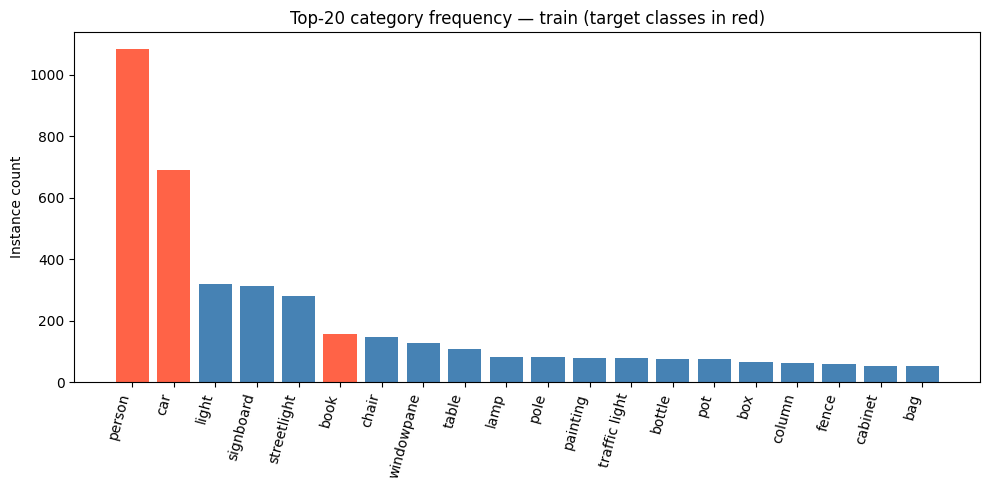

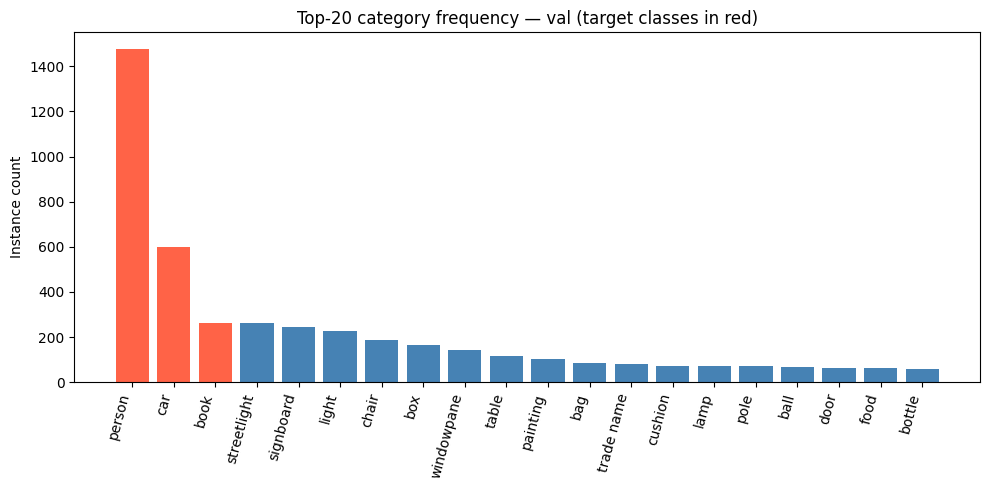

In [9]:
def plot_class_distribution(json_data, split_name):
    cat_map = {c["id"]: c["name"] for c in json_data["categories"]}
    cnt = Counter(a["category_id"] for a in json_data["annotations"])
    items = sorted(cnt.items(), key=lambda x: -x[1])[:20]  # top 20 for readability
    names = [cat_map[i] for i, _ in items]
    counts = [n for _, n in items]
    colors = ["tomato" if i in TARGET_CATEGORIES else "steelblue" for i, _ in items]

    plt.figure(figsize=(10, 5))
    plt.bar(names, counts, color=colors)
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Instance count")
    plt.title(f"Top-20 category frequency — {split_name} (target classes in red)")
    plt.tight_layout()
    plt.show()

plot_class_distribution(train_json, "train")
plot_class_distribution(val_json, "val")

In [10]:
def target_class_counts(json_data, split_name):
    cnt = Counter(a["category_id"] for a in json_data["annotations"] if a["category_id"] in TARGET_CATEGORIES)
    print(f"--- {split_name} target-class instance counts ---")
    for cid, name in TARGET_CATEGORIES.items():
        print(f"  {name:10s}: {cnt.get(cid, 0)}")

target_class_counts(train_json, "train")
target_class_counts(val_json, "val")

--- train target-class instance counts ---
  person    : 1084
  car       : 689
  book      : 155
  airplane  : 13
--- val target-class instance counts ---
  person    : 1477
  car       : 598
  book      : 261
  airplane  : 15


### 3.3 Object size / area distribution for target classes

<Figure size 800x500 with 0 Axes>

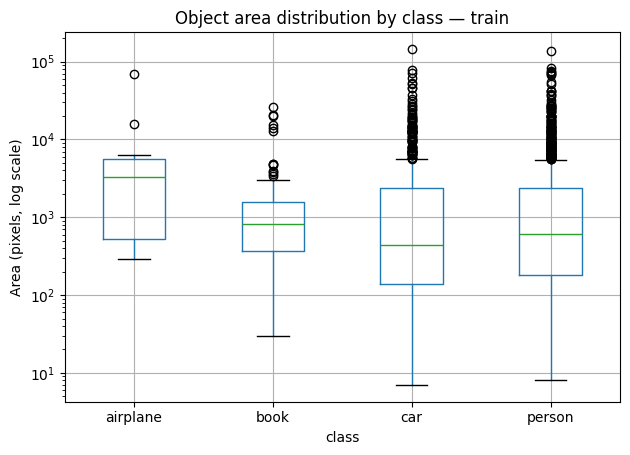

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
airplane,13.0,8740.615385,18881.860892,295.0,526.00,3270.0,5542.00,70072.0
book,155.0,1716.309677,3564.305968,30.0,366.00,816.0,1549.50,26084.0
car,689.0,3064.613933,9138.092455,7.0,140.00,436.0,2350.00,145052.0
person,1084.0,3192.035055,8732.490566,8.0,183.75,610.0,2346.75,136904.0


In [11]:
def plot_area_distribution(json_data, split_name):
    rows = []
    for a in json_data["annotations"]:
        if a["category_id"] in TARGET_CATEGORIES:
            rows.append({"class": TARGET_CATEGORIES[a["category_id"]], "area": a["area"]})
    df = pd.DataFrame(rows)

    plt.figure(figsize=(8, 5))
    df.boxplot(column="area", by="class")
    plt.yscale("log")
    plt.ylabel("Area (pixels, log scale)")
    plt.title(f"Object area distribution by class — {split_name}")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

    return df.groupby("class")["area"].describe()

train_area_stats = plot_area_distribution(train_json, "train")
train_area_stats

### 3.4 Sample visualization — image with mask overlay

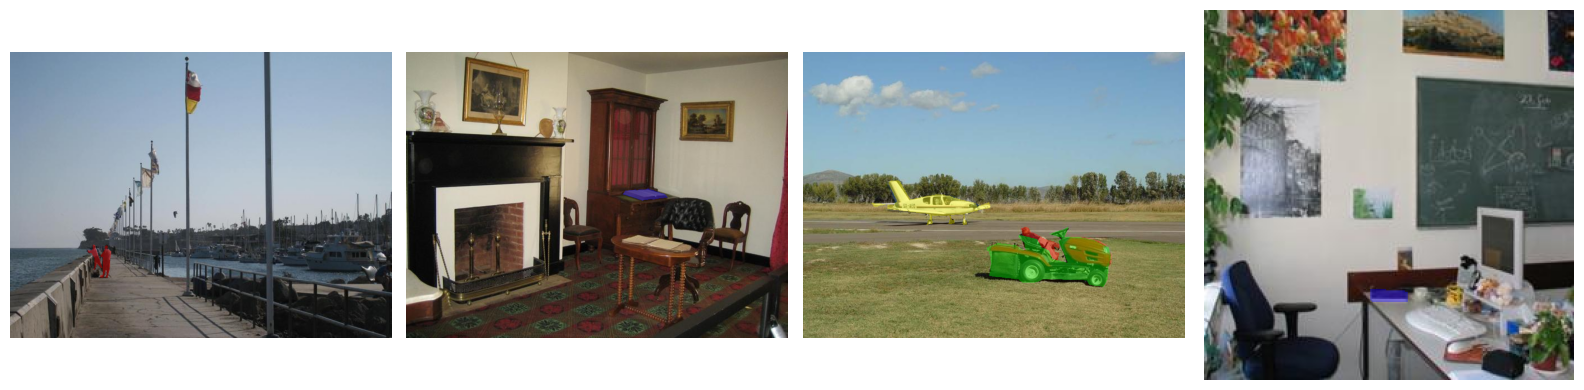

In [12]:
def show_sample(coco, img_dir, img_id, ax=None):
    img_info = coco.imgs[img_id]
    image = np.array(Image.open(os.path.join(img_dir, img_info["file_name"])).convert("RGB"))
    mask = np.zeros(image.shape[:2], dtype=np.uint8)

    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=list(TARGET_CATEGORIES.keys()))
    anns = sorted(coco.loadAnns(ann_ids), key=lambda a: -a["area"])
    for a in anns:
        m = coco.annToMask(a)
        mask[m == 1] = CAT_ID_TO_LABEL[a["category_id"]]

    overlay = image.copy()
    colors = {1: (255,0,0), 2: (0,255,0), 3: (0,0,255), 4: (255,255,0)}
    for label, color in colors.items():
        overlay[mask == label] = color

    blended = (0.6 * image + 0.4 * overlay).astype(np.uint8)
    if ax is None:
        plt.figure(figsize=(5,5))
        plt.imshow(blended); plt.axis("off"); plt.show()
    else:
        ax.imshow(blended); ax.axis("off")

fig, axes = plt.subplots(1, 4, figsize=(16,4))
sample_ids = list(coco_train.imgs.keys())[:4]
for ax, img_id in zip(axes, sample_ids):
    show_sample(coco_train, TRAIN_DIR, img_id, ax=ax)
plt.tight_layout()
plt.show()

## 4. Dataset & DataLoader Construction
### 4.1 Compulsory checks/requirements specific to a segmentation `Dataset` class
- Masks must be built at the **same resolution** as the source image before any resize
- Class-overlap handling: when instances overlap, decide a consistent priority (here: larger objects drawn first, smaller drawn last, so small objects aren't erased)
- Image and mask must receive the **same spatial transform** (flip/crop/resize) — using separate/uncoordinated augmentation pipelines for image vs mask is a common silent bug
- Normalization stats should match the encoder's pretrained backbone (ImageNet mean/std here)

In [13]:
TARGET_CATEGORIES = {4: 1, 9: 2, 40: 3, 59: 4}   # category_id -> label
CLASS_NAMES = ["background", "person", "car", "book", "airplane"]
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 256

class ADE20KFourClass(Dataset):
    def __init__(self, ann_file, img_dir, transform=None):
        self.coco = COCO(ann_file)
        self.img_dir = img_dir
        self.transform = transform
        self.image_ids = sorted(self.coco.imgs.keys())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.imgs[img_id]
        image = np.array(Image.open(os.path.join(self.img_dir, img_info["file_name"])).convert("RGB"))

        h, w = img_info["height"], img_info["width"]
        mask = np.zeros((h, w), dtype=np.uint8)

        ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=list(TARGET_CATEGORIES.keys()))
        anns = sorted(self.coco.loadAnns(ann_ids), key=lambda a: -a["area"])
        for ann in anns:
            m = self.coco.annToMask(ann)
            mask[m == 1] = TARGET_CATEGORIES[ann["category_id"]]

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented["image"], augmented["mask"]

        return image, mask.long()

In [14]:
# Same spatial transform applied jointly to image + mask (Albumentations handles this)
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [15]:
train_ds = ADE20KFourClass(TRAIN_ANN, TRAIN_DIR, transform=train_transform)
val_ds   = ADE20KFourClass(VAL_ANN, VAL_DIR, transform=val_transform)

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")
img, mask = train_ds[0]
print("Image tensor shape:", img.shape, "| Mask tensor shape:", mask.shape, "| unique labels:", torch.unique(mask))

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Train samples: 350 | Val samples: 350
Image tensor shape: torch.Size([3, 256, 256]) | Mask tensor shape: torch.Size([256, 256]) | unique labels: tensor([0, 2])


In [16]:
# Class-weighted loss to address the severe airplane imbalance found in EDA (section 3.2)
def compute_class_weights(json_data):
    counts = np.zeros(NUM_CLASSES)
    for a in json_data["annotations"]:
        if a["category_id"] in TARGET_CATEGORIES:
            counts[TARGET_CATEGORIES[a["category_id"]]] += 1
    counts[0] = counts[1:].sum()  # rough background proxy so it isn't weighted absurdly high
    weights = 1.0 / np.log(1.02 + counts / counts.sum())
    weights = weights / weights.sum() * NUM_CLASSES
    return torch.tensor(weights, dtype=torch.float32)

class_weights = compute_class_weights(train_json).to(device)
print("Class weights:", dict(zip(CLASS_NAMES, class_weights.tolist())))

Class weights: {'background': 0.16524341702461243, 'person': 0.2643050253391266, 'car': 0.3839057981967926, 'book': 1.1887990236282349, 'airplane': 2.997746706008911}


## 5. Shared Training / Evaluation Utilities
Defined once, reused for both models — kept in their own cell so each model section only calls a function rather than duplicating logic.

In [17]:
def dice_iou_per_class(preds, targets, num_classes=NUM_CLASSES):
    intersection = torch.zeros(num_classes)
    union = torch.zeros(num_classes)
    pred_sum = torch.zeros(num_classes)
    gt_sum = torch.zeros(num_classes)
    for c in range(num_classes):
        p = (preds == c)
        g = (targets == c)
        intersection[c] += (p & g).sum().item()
        union[c] += (p | g).sum().item()
        pred_sum[c] += p.sum().item()
        gt_sum[c] += g.sum().item()
    iou = intersection / union.clamp(min=1)
    dice = (2 * intersection) / (pred_sum + gt_sum).clamp(min=1)
    return iou, dice


def train_one_model(model, train_loader, val_loader, epochs=15, lr=1e-4, weights=None):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_running_loss += loss.item() * images.size(0)
        val_loss = val_running_loss / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    return history


@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    all_iou = torch.zeros(NUM_CLASSES)
    all_dice = torch.zeros(NUM_CLASSES)
    n_batches = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        preds = torch.argmax(model(images), dim=1).cpu()
        iou, dice = dice_iou_per_class(preds, masks.cpu())
        all_iou += iou
        all_dice += dice
        n_batches += 1
    return all_iou / n_batches, all_dice / n_batches

## 6. Model 1 — U-Net (EfficientNet-B0 encoder)

In [18]:
model_effnet = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    classes=NUM_CLASSES,
    activation=None,
)
print(sum(p.numel() for p in model_effnet.parameters() if p.requires_grad), "trainable parameters")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

6252049 trainable parameters


In [19]:
history_effnet = train_one_model(
    model_effnet, train_loader, val_loader,
    epochs=15, lr=1e-4, weights=class_weights
)

Epoch 1/15 | train_loss=1.5518 | val_loss=1.3572
Epoch 2/15 | train_loss=1.1913 | val_loss=1.0165
Epoch 3/15 | train_loss=0.9177 | val_loss=0.7866
Epoch 4/15 | train_loss=0.7221 | val_loss=0.6273
Epoch 5/15 | train_loss=0.5889 | val_loss=0.5244
Epoch 6/15 | train_loss=0.4883 | val_loss=0.4369
Epoch 7/15 | train_loss=0.4212 | val_loss=0.3927
Epoch 8/15 | train_loss=0.3659 | val_loss=0.3635
Epoch 9/15 | train_loss=0.3277 | val_loss=0.3248
Epoch 10/15 | train_loss=0.3001 | val_loss=0.3246
Epoch 11/15 | train_loss=0.2679 | val_loss=0.2903
Epoch 12/15 | train_loss=0.2519 | val_loss=0.2806
Epoch 13/15 | train_loss=0.2328 | val_loss=0.2752
Epoch 14/15 | train_loss=0.2191 | val_loss=0.2690
Epoch 15/15 | train_loss=0.2026 | val_loss=0.2615


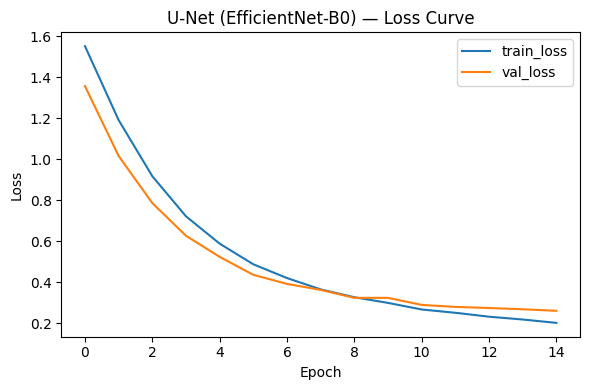

In [20]:
torch.save(model_effnet.state_dict(), "unet_efficientnet_b0.pth")

plt.figure(figsize=(6,4))
plt.plot(history_effnet["train_loss"], label="train_loss")
plt.plot(history_effnet["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("U-Net (EfficientNet-B0) — Loss Curve")
plt.legend(); plt.tight_layout(); plt.show()

## 7. Model 2 — U-Net (MobileNetV2 encoder)

In [21]:
model_mobilenet = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",
    classes=NUM_CLASSES,
    activation=None,
)
print(sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad), "trainable parameters")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

6629525 trainable parameters


In [22]:
history_mobilenet = train_one_model(
    model_mobilenet, train_loader, val_loader,
    epochs=15, lr=1e-4, weights=class_weights
)

Epoch 1/15 | train_loss=1.6076 | val_loss=1.3778
Epoch 2/15 | train_loss=1.1391 | val_loss=0.9558
Epoch 3/15 | train_loss=0.8522 | val_loss=0.7358
Epoch 4/15 | train_loss=0.6828 | val_loss=0.6131
Epoch 5/15 | train_loss=0.5716 | val_loss=0.5312
Epoch 6/15 | train_loss=0.4823 | val_loss=0.4647
Epoch 7/15 | train_loss=0.4289 | val_loss=0.4092
Epoch 8/15 | train_loss=0.3692 | val_loss=0.3731
Epoch 9/15 | train_loss=0.3322 | val_loss=0.3415
Epoch 10/15 | train_loss=0.3016 | val_loss=0.3256
Epoch 11/15 | train_loss=0.2707 | val_loss=0.3041
Epoch 12/15 | train_loss=0.2650 | val_loss=0.3243
Epoch 13/15 | train_loss=0.2546 | val_loss=0.2790
Epoch 14/15 | train_loss=0.2278 | val_loss=0.2802
Epoch 15/15 | train_loss=0.2189 | val_loss=0.2747


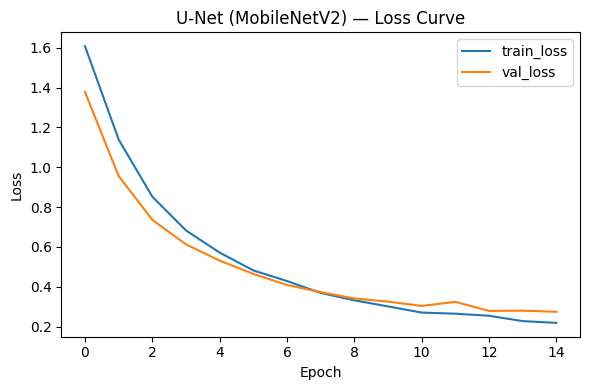

In [23]:
torch.save(model_mobilenet.state_dict(), "unet_mobilenet_v2.pth")

plt.figure(figsize=(6,4))
plt.plot(history_mobilenet["train_loss"], label="train_loss")
plt.plot(history_mobilenet["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("U-Net (MobileNetV2) — Loss Curve")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Model Comparison

In [24]:
iou_effnet, dice_effnet = evaluate_model(model_effnet, val_loader)
iou_mobilenet, dice_mobilenet = evaluate_model(model_mobilenet, val_loader)

results = {
    "U-Net (EfficientNet-B0)": (iou_effnet, dice_effnet),
    "U-Net (MobileNetV2)": (iou_mobilenet, dice_mobilenet),
}

In [25]:
rows = []
for cname_idx, cname in enumerate(CLASS_NAMES):
    row = {"Class": cname}
    for model_name, (iou, dice) in results.items():
        row[f"{model_name} IoU"] = round(iou[cname_idx].item(), 4)
        row[f"{model_name} Dice"] = round(dice[cname_idx].item(), 4)
    rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df

,Class,U-Net (EfficientNet-B0) IoU,U-Net (EfficientNet-B0) Dice,U-Net (MobileNetV2) IoU,U-Net (MobileNetV2) Dice
0,background,0.9462,0.9722,0.9545,0.9765
1,person,0.4490,0.5992,0.4592,0.6068
2,car,0.3946,0.5154,0.3990,0.5043
3,book,0.0643,0.1004,0.0000,0.0000
4,airplane,0.0000,0.0001,0.0050,0.0090


In [26]:
# Mean IoU/Dice over FOREGROUND classes only (excludes background — background
# dominates pixel count and would otherwise mask true foreground performance)
summary_rows = []
for model_name, (iou, dice) in results.items():
    summary_rows.append({
        "Model": model_name,
        "Mean IoU (fg classes)": round(iou[1:].mean().item(), 4),
        "Mean Dice (fg classes)": round(dice[1:].mean().item(), 4),
        "Trainable Params": sum(p.numel() for p in (model_effnet if "EfficientNet" in model_name else model_mobilenet).parameters())
    })
summary_df = pd.DataFrame(summary_rows)
summary_df

,Model,Mean IoU (fg classes),Mean Dice (fg classes),Trainable Params
0,U-Net (EfficientNet-B0),0.2270,0.3038,6252049
1,U-Net (MobileNetV2),0.2158,0.2800,6629525


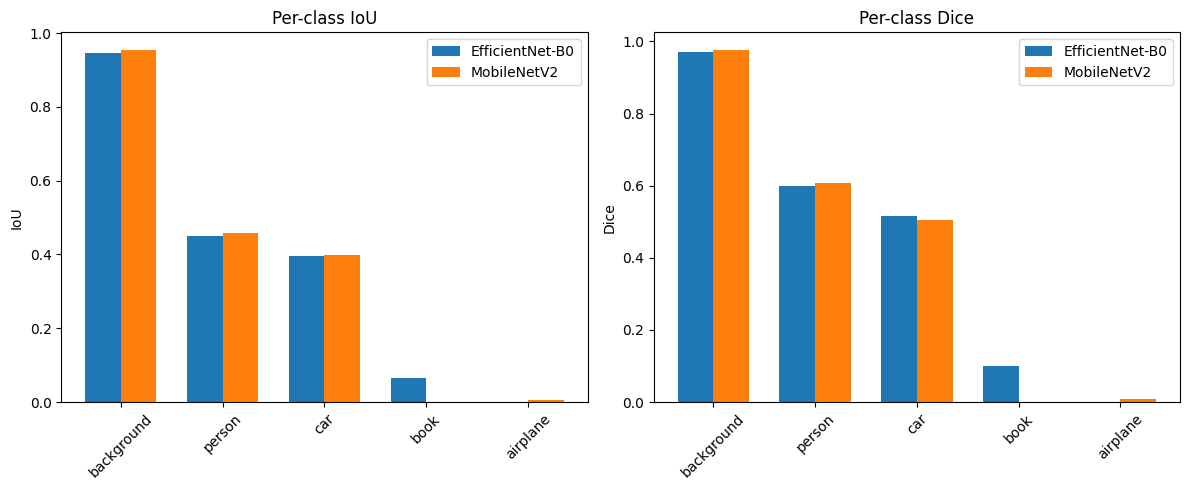

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
x = np.arange(len(CLASS_NAMES))
width = 0.35

axes[0].bar(x - width/2, iou_effnet.numpy(), width, label="EfficientNet-B0")
axes[0].bar(x + width/2, iou_mobilenet.numpy(), width, label="MobileNetV2")
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_NAMES, rotation=45)
axes[0].set_ylabel("IoU"); axes[0].set_title("Per-class IoU"); axes[0].legend()

axes[1].bar(x - width/2, dice_effnet.numpy(), width, label="EfficientNet-B0")
axes[1].bar(x + width/2, dice_mobilenet.numpy(), width, label="MobileNetV2")
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASS_NAMES, rotation=45)
axes[1].set_ylabel("Dice"); axes[1].set_title("Per-class Dice"); axes[1].legend()

plt.tight_layout()
plt.show()

### 8.1 Qualitative comparison — predictions vs. ground truth

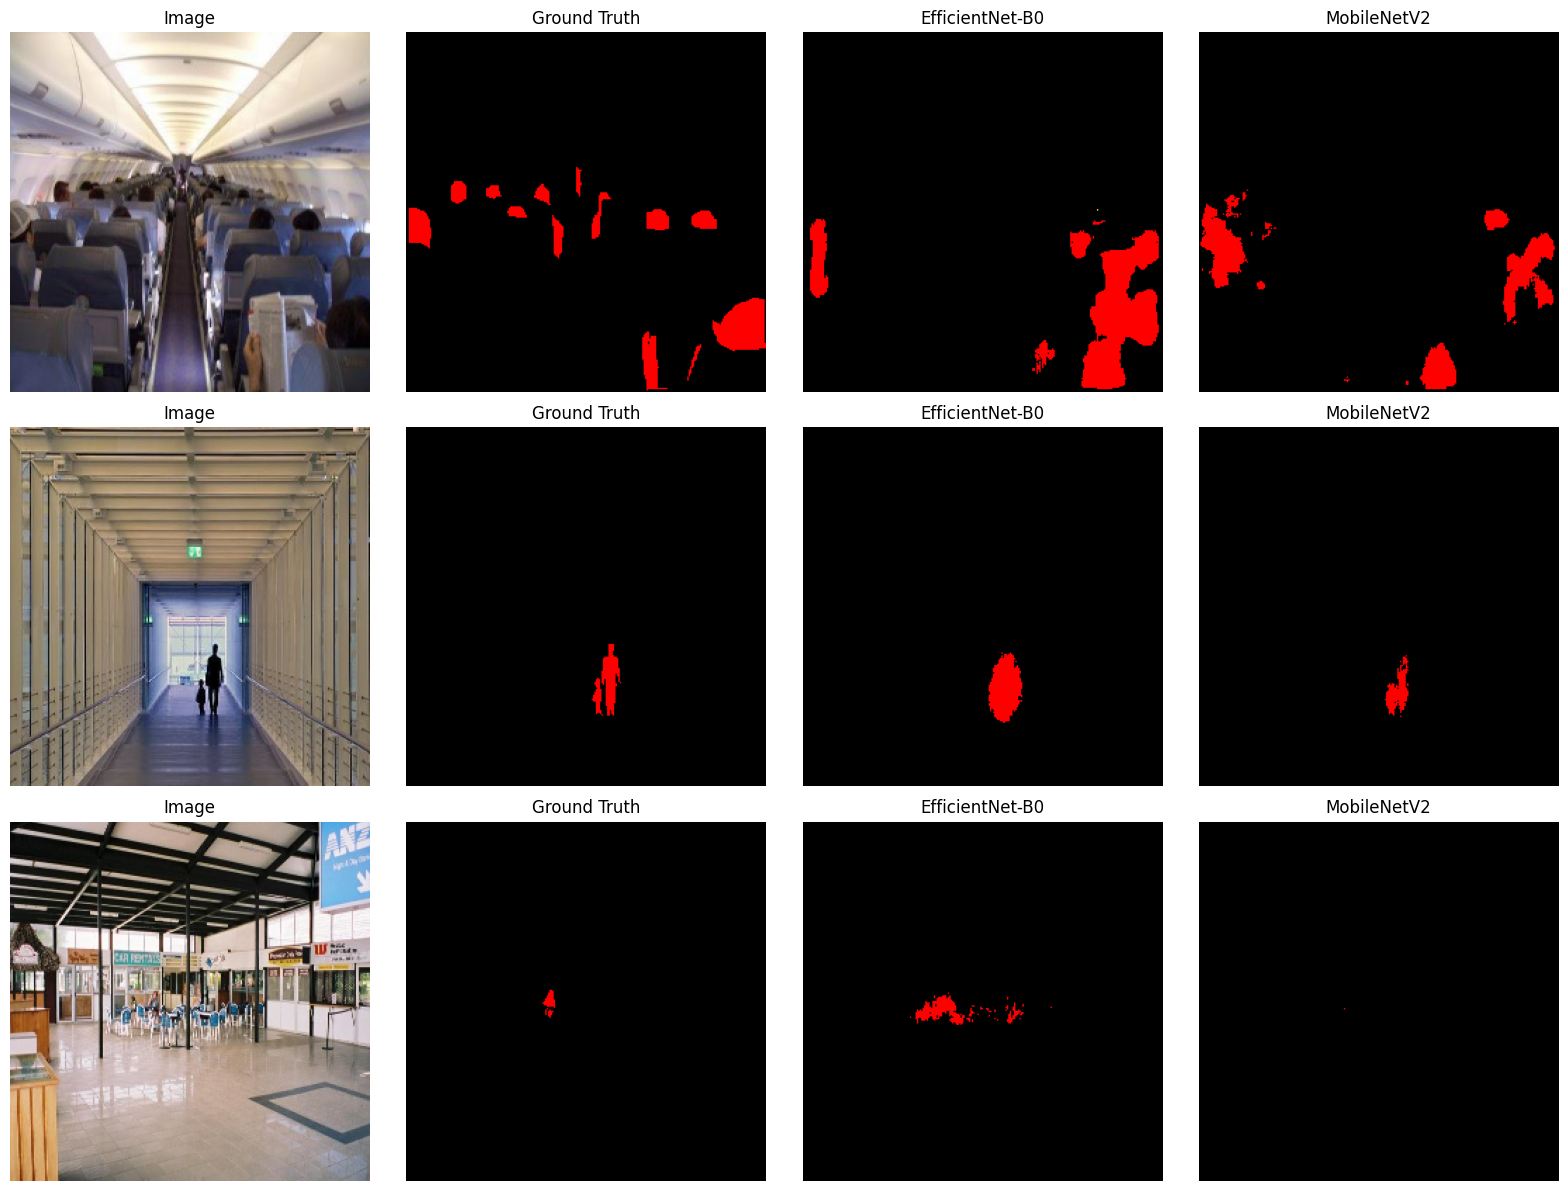

In [28]:
@torch.no_grad()
def visualize_predictions(models_dict, dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2 + len(models_dict), figsize=(4*(2+len(models_dict)), 4*num_samples))
    colors = np.array([[0,0,0],[255,0,0],[0,255,0],[0,0,255],[255,255,0]], dtype=np.uint8)

    for row in range(num_samples):
        image, mask = dataset[row]
        img_np = image.permute(1,2,0).numpy()
        img_np = (img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
        img_np = np.clip(img_np, 0, 1)

        axes[row, 0].imshow(img_np); axes[row, 0].set_title("Image"); axes[row, 0].axis("off")
        axes[row, 1].imshow(colors[mask.numpy()]); axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis("off")

        for col, (name, model) in enumerate(models_dict.items(), start=2):
            model.eval()
            pred = torch.argmax(model(image.unsqueeze(0).to(device)), dim=1).squeeze(0).cpu().numpy()
            axes[row, col].imshow(colors[pred]); axes[row, col].set_title(name); axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(
    {"EfficientNet-B0": model_effnet, "MobileNetV2": model_mobilenet},
    val_ds,
    num_samples=3
)